In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
dataset_path = r"C:\Project\Klasifikasi_Bunga_CNN\flowers"

print("Isi folder dataset:")
print(os.listdir(dataset_path))

print("\nJumlah gambar setiap kelas:")
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)), "gambar")

Isi folder dataset:
['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

Jumlah gambar setiap kelas:
daisy : 764 gambar
dandelion : 1052 gambar
rose : 784 gambar
sunflower : 734 gambar
tulip : 984 gambar


In [3]:
img_size = 150
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Label kelas:", train_data.class_indices)

Found 3458 images belonging to 5 classes.
Found 860 images belonging to 5 classes.
Label kelas: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


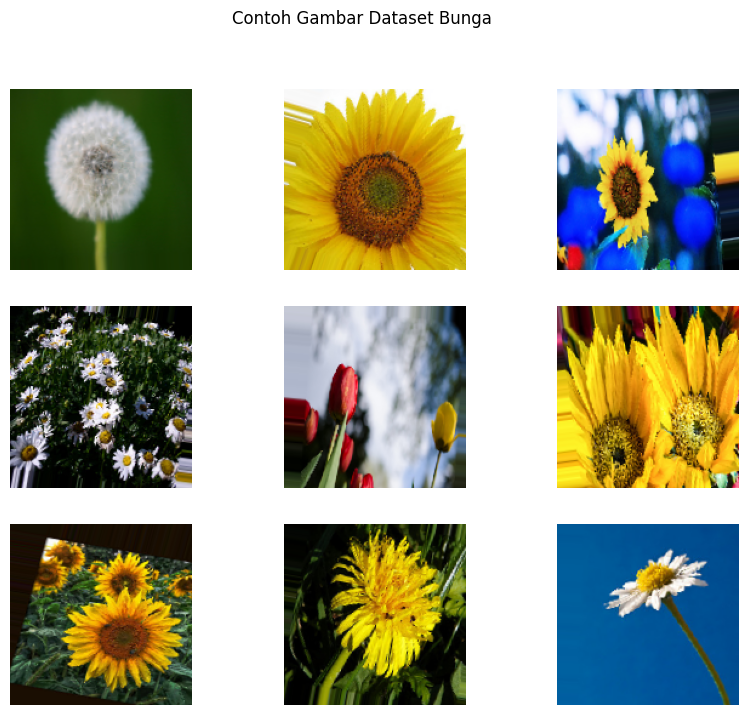

In [4]:
images, labels = next(train_data)

plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.suptitle("Contoh Gambar Dataset Bunga")
plt.show()

In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(img_size, img_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(5, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\hicup\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 150, 150, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 75, 75, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 37, 37, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 37, 37, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 18, 18, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 18, 18, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 489,669 (1.87 MB)

 Trainable params: 488,709 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=0.00001
    ),

    ModelCheckpoint(
        "model_bunga_terbaik.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [7]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=50,
    callbacks=callbacks
)

C:\Users\hicup\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 61s 514ms/step - accuracy: 0.3923 - loss: 1.5093 - val_accuracy: 0.2442 - val_loss: 2.3017 - learning_rate: 5.0000e-04
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 56s 511ms/step - accuracy: 0.5342 - loss: 1.1666 - val_accuracy: 0.2442 - val_loss: 2.9347 - learning_rate: 5.0000e-04
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 56s 513ms/step - accuracy: 0.5710 - loss: 1.0909 - val_accuracy: 0.2477 - val_loss: 2.2229 - learning_rate: 5.0000e-04
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 56s 515ms/step - accuracy: 0.6089 - loss: 0.9871 - val_accuracy: 0.3395 - val_loss: 1.7564 - learning_rate: 5.0000e-04
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 57s 518ms/step - accuracy: 0.6298 - loss: 0.9915 - val_accuracy: 0.6244 - val_loss: 0.9867 - learning_rate: 5.0000e-04
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 56s 514ms/step - accuracy: 0.6375 - loss: 0.9152 - val_accuracy: 0.6302 - val_loss: 0.9787 - learning_rate: 5.0000e-04
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 55s 50

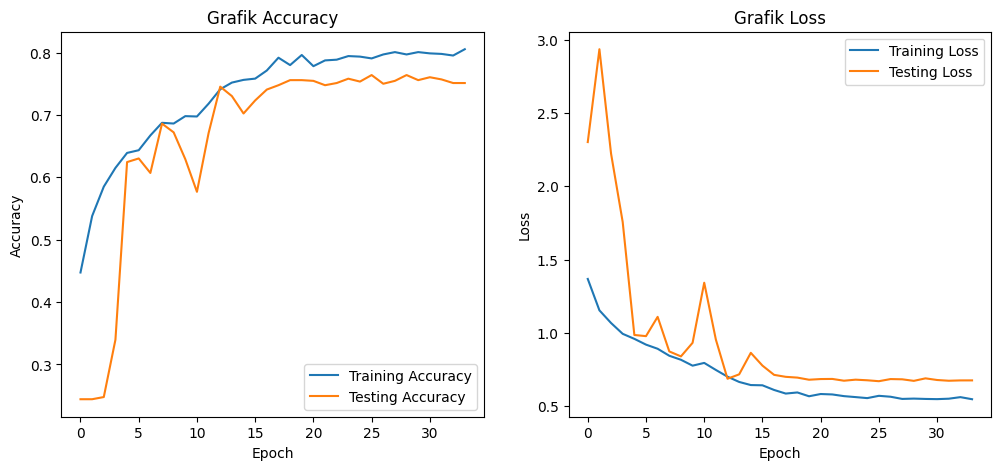

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Testing Accuracy")
plt.title("Grafik Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Testing Loss")
plt.title("Grafik Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step


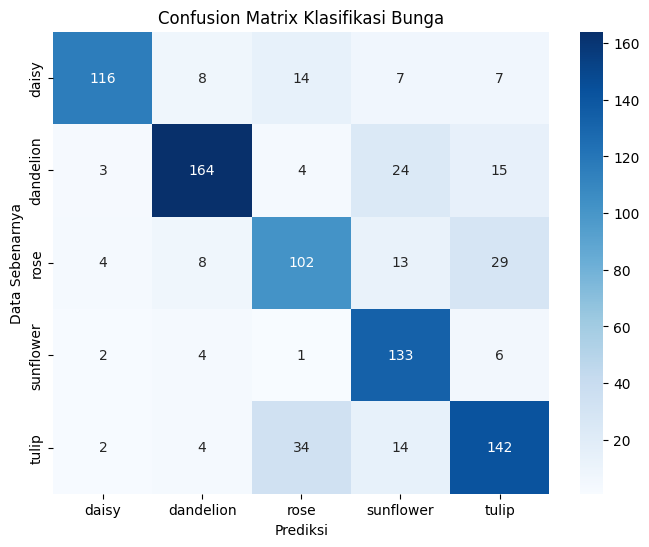

              precision    recall  f1-score   support

       daisy       0.91      0.76      0.83       152
   dandelion       0.87      0.78      0.82       210
        rose       0.66      0.65      0.66       156
   sunflower       0.70      0.91      0.79       146
       tulip       0.71      0.72      0.72       196

    accuracy                           0.76       860
   macro avg       0.77      0.77      0.76       860
weighted avg       0.77      0.76      0.77       860



In [9]:
test_data.reset()

prediksi = model.predict(test_data)
y_pred = np.argmax(prediksi, axis=1)
y_true = test_data.classes

class_names = list(test_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Prediksi")
plt.ylabel("Data Sebenarnya")
plt.title("Confusion Matrix Klasifikasi Bunga")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step


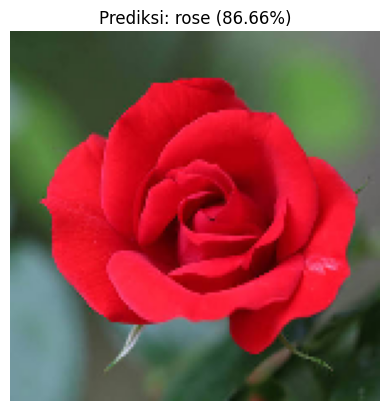

Hasil prediksi: rose
Confidence: 86.65984 %


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

model = load_model("model_bunga_terbaik.keras")

class_names = ["daisy", "dandelion", "rose", "sunflower", "tulip"]

img_path = r"C:\Project\Klasifikasi_Bunga_CNN\test_gambar\tesrose.jpg"

img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediksi: {predicted_class} ({confidence:.2f}%)")
plt.show()

print("Hasil prediksi:", predicted_class)
print("Confidence:", confidence, "%")

In [12]:
model.save("flower_cnn_model.keras")
print("Model berhasil disimpan.")

Model berhasil disimpan.


========================================================================

# Percobaan 2

In [ ]:
========================================================================

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
dataset_path = r"C:\Project\Klasifikasi_Bunga_CNN\flowers"

IMG_SIZE = 180
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print(train_data.class_indices)

Found 3458 images belonging to 5 classes.
Found 860 images belonging to 5 classes.
{'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


In [3]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.15),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.20),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.30),

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.45),

    Dense(128, activation="relu"),
    Dropout(0.30),

    Dense(5, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\hicup\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 180, 180, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 180, 180, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 180, 180, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 180, 180, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 90, 90, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 90, 90, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 90, 90, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 90, 90, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 90, 90, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 45, 45, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 45, 45, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 45, 45, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 45, 45, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 45, 45, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 22, 22, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 685,349 (2.61 MB)

 Trainable params: 683,429 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [4]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=0.00001
    ),

    ModelCheckpoint(
        "flower_cnn_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [5]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=60,
    callbacks=callbacks
)

C:\Users\hicup\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
109/109 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.3279 - loss: 1.8541 - val_accuracy: 0.2442 - val_loss: 2.4283 - learning_rate: 3.0000e-04
Epoch 2/60
109/109 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.4591 - loss: 1.4866 - val_accuracy: 0.2442 - val_loss: 3.7955 - learning_rate: 3.0000e-04
Epoch 3/60
109/109 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.4793 - loss: 1.3745 - val_accuracy: 0.2442 - val_loss: 3.5321 - learning_rate: 3.0000e-04
Epoch 4/60
109/109 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.4920 - loss: 1.3318 - val_accuracy: 0.3244 - val_loss: 2.1794 - learning_rate: 3.0000e-04
Epoch 5/60
109/109 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.5397 - loss: 1.2397 - val_accuracy: 0.4128 - val_loss: 1.4849 - learning_rate: 3.0000e-04
Epoch 6/60
109/109 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.5604 - loss: 1.1433 - val_accuracy: 0.3837 - val_loss: 1.9421 - learning_rate: 3.0000e-04
Epoch 7/60
109/109 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - acc

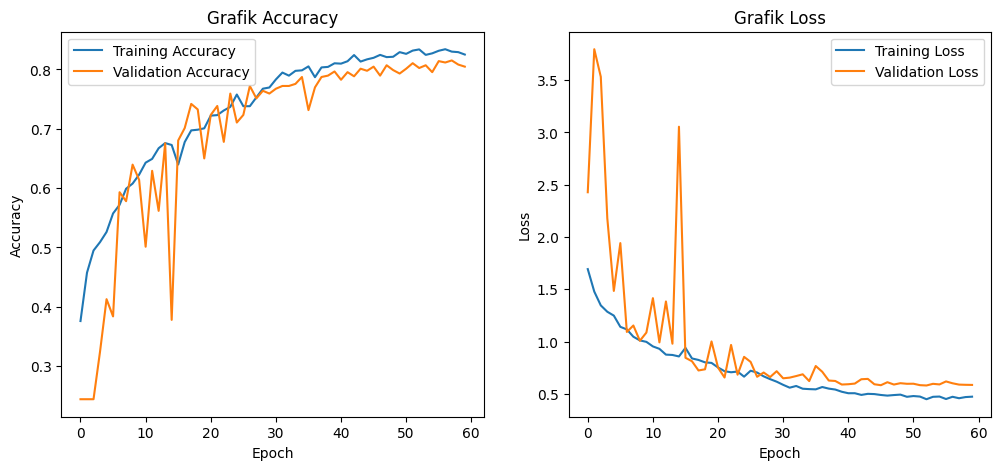

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Grafik Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Grafik Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step


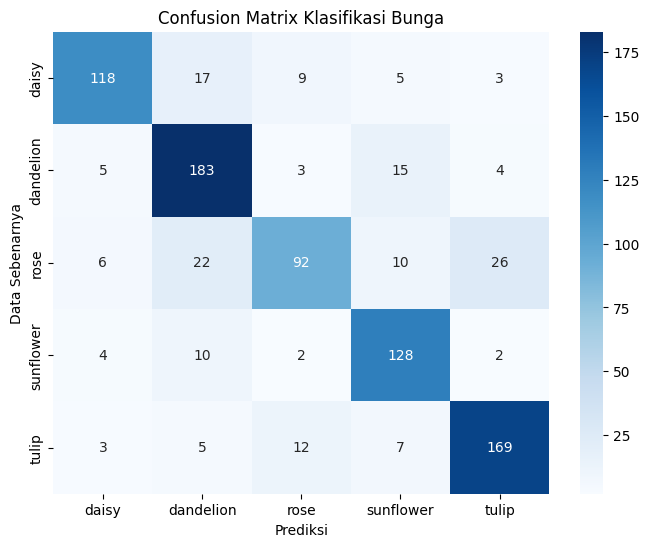

              precision    recall  f1-score   support

       daisy       0.87      0.78      0.82       152
   dandelion       0.77      0.87      0.82       210
        rose       0.78      0.59      0.67       156
   sunflower       0.78      0.88      0.82       146
       tulip       0.83      0.86      0.84       196

    accuracy                           0.80       860
   macro avg       0.80      0.80      0.80       860
weighted avg       0.80      0.80      0.80       860



In [7]:
val_data.reset()

pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

class_names = list(val_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Prediksi")
plt.ylabel("Data Sebenarnya")
plt.title("Confusion Matrix Klasifikasi Bunga")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [8]:
model.save("flower_cnn_model2.keras")
print("Model berhasil disimpan sebagai flower_cnn_model2.keras")

Model berhasil disimpan sebagai flower_cnn_model2.keras
